In [1]:
import pandas as pd

df=pd.read_csv('/Users/gretawette/Documents/Thesis/03_Framing/outputs/media_framing_final_run_5_4mini_classifications.csv')

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11975 entries, 0 to 11974
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   hit_id                 11975 non-null  str  
 1   row_id                 11975 non-null  int64
 2   source                 11975 non-null  str  
 3   Title                  11975 non-null  str  
 4   hit_text               11975 non-null  str  
 5   context_idx            11975 non-null  int64
 6   count_hits             11975 non-null  int64
 7   count_unique_entities  11975 non-null  int64
 8   context_window         11975 non-null  str  
 9   model                  11975 non-null  str  
 10  response_id            11975 non-null  str  
 11  category               11975 non-null  str  
 12  evidence               2829 non-null   str  
 13  raw_response_json      11975 non-null  str  
dtypes: int64(4), str(10)
memory usage: 1.3 MB


In [3]:
df.category.value_counts()

category
NEUTRAL                             8837
VERZERRUNG/MANIPULATION             1301
POSITIONS-/PARTEILICHKEITS-BIAS      848
DISINFORMATION/FALSCHDARSTELLUNG     343
VERSAGEN/INKOMPETENZ                 337
IRRELEVANT                           309
Name: count, dtype: int64

### Remove where category is irrelevant

In [4]:
# Remove rows where the 'category' is 'IRRELEVANT'
df = df[df['category'] != 'IRRELEVANT']

In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 11666 entries, 0 to 11974
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   hit_id                 11666 non-null  str  
 1   row_id                 11666 non-null  int64
 2   source                 11666 non-null  str  
 3   Title                  11666 non-null  str  
 4   hit_text               11666 non-null  str  
 5   context_idx            11666 non-null  int64
 6   count_hits             11666 non-null  int64
 7   count_unique_entities  11666 non-null  int64
 8   context_window         11666 non-null  str  
 9   model                  11666 non-null  str  
 10  response_id            11666 non-null  str  
 11  category               11666 non-null  str  
 12  evidence               2829 non-null   str  
 13  raw_response_json      11666 non-null  str  
dtypes: int64(4), str(10)
memory usage: 1.3 MB


In [6]:
df['category'].value_counts()

category
NEUTRAL                             8837
VERZERRUNG/MANIPULATION             1301
POSITIONS-/PARTEILICHKEITS-BIAS      848
DISINFORMATION/FALSCHDARSTELLUNG     343
VERSAGEN/INKOMPETENZ                 337
Name: count, dtype: int64

In [7]:
df['source'].value_counts()

source
Tagesschau           4327
Tichys_Einblick      2208
Nius                 1969
RT_de                1815
Antispiegel           513
Compact               456
Deutschlandkurier     378
Name: count, dtype: int64

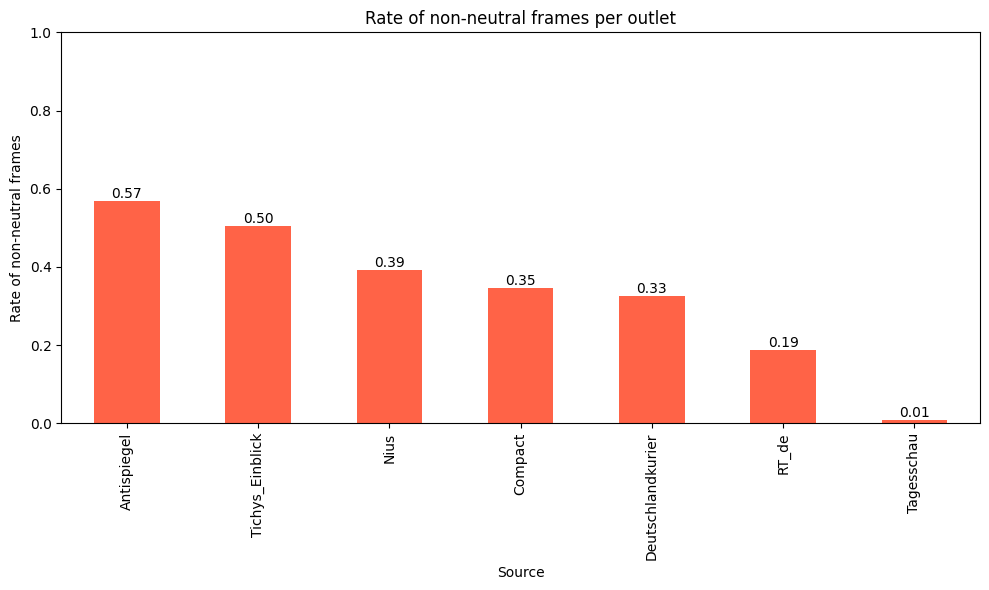

In [8]:
import matplotlib.pyplot as plt

# Normalize potential misspelling
df = df.rename(columns=lambda x: x.strip())
if 'suorce' in df.columns:
    df = df.rename(columns={'suorce': 'source'})
if 'categorty' in df.columns:
    df = df.rename(columns={'categorty': 'category'})

# Compute # non-neutral frames per outlet
non_neutral = df[~df['category'].isin(['NEUTRAL', 'IRRELEVANT'])].groupby('source').size()
total = df.groupby('source').size()
rate = (non_neutral / total).fillna(0).sort_values(ascending=False)

# Plot with bar labels
plt.figure(figsize=(10,6))
ax = rate.plot(kind='bar', color='tomato')
plt.ylabel("Rate of non-neutral frames")
plt.xlabel("Source")
plt.title("Rate of non-neutral frames per outlet")
plt.ylim(0, 1)
plt.tight_layout()

# Add data labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.2f}", 
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10)

plt.show()

In [9]:
# Remove all rows where source is 'Tagesschau'
df = df[df['source'] != 'Tagesschau']

In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 7339 entries, 0 to 7604
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   hit_id                 7339 non-null   str  
 1   row_id                 7339 non-null   int64
 2   source                 7339 non-null   str  
 3   Title                  7339 non-null   str  
 4   hit_text               7339 non-null   str  
 5   context_idx            7339 non-null   int64
 6   count_hits             7339 non-null   int64
 7   count_unique_entities  7339 non-null   int64
 8   context_window         7339 non-null   str  
 9   model                  7339 non-null   str  
 10  response_id            7339 non-null   str  
 11  category               7339 non-null   str  
 12  evidence               2798 non-null   str  
 13  raw_response_json      7339 non-null   str  
dtypes: int64(4), str(10)
memory usage: 860.0 KB


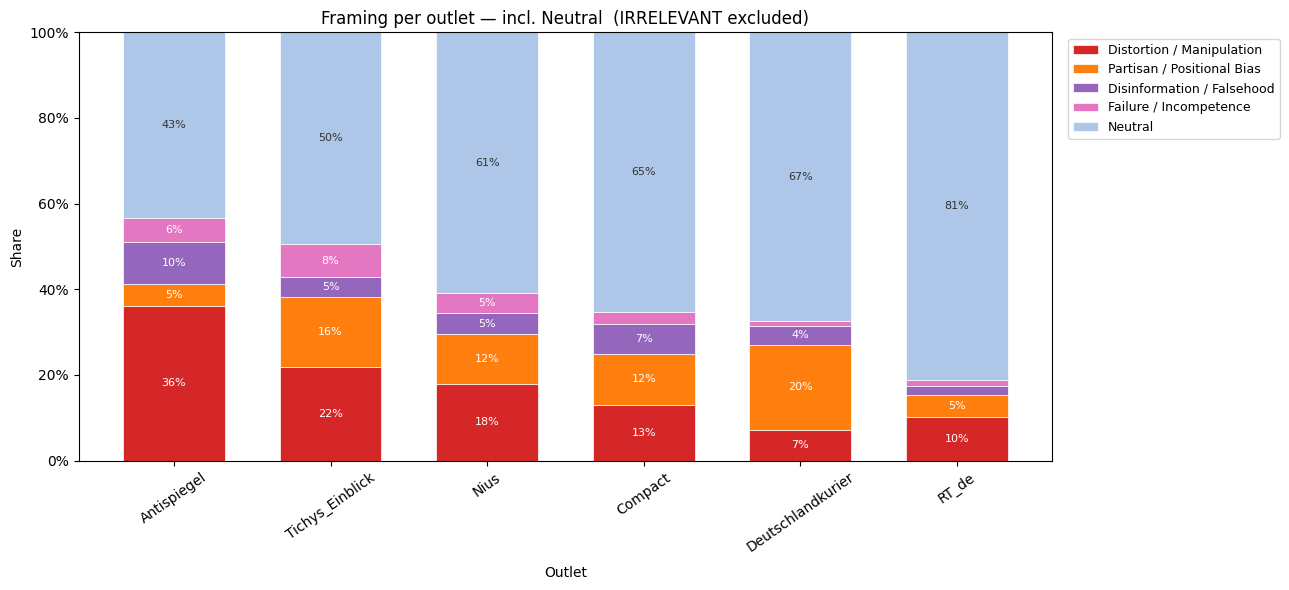

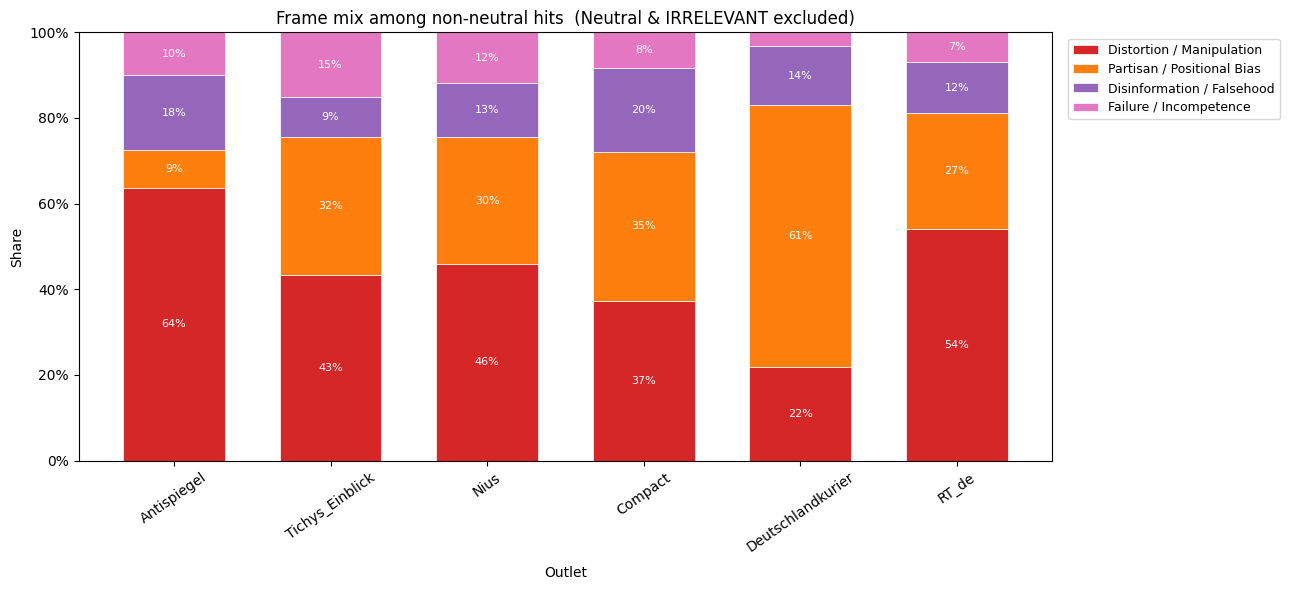

In [11]:

import numpy as np

# ── English labels ────────────────────────────────────────────────────────────
CATEGORY_EN = {
    "VERZERRUNG/MANIPULATION":            "Distortion / Manipulation",
    "POSITIONS-/PARTEILICHKEITS-BIAS":    "Partisan / Positional Bias",
    "DISINFORMATION/FALSCHDARSTELLUNG":   "Disinformation / Falsehood",
    "VERSAGEN/INKOMPETENZ":               "Failure / Incompetence",
    "NEUTRAL":                            "Neutral",
}
FRAMING_COLS = [
    "Distortion / Manipulation",
    "Partisan / Positional Bias",
    "Disinformation / Falsehood",
    "Failure / Incompetence",
]
COLORS = {
    "Distortion / Manipulation": "#d62728",
    "Partisan / Positional Bias": "#ff7f0e",
    "Disinformation / Falsehood": "#9467bd",
    "Failure / Incompetence":    "#e377c2",
    "Neutral":                   "#aec7e8",
}

# Add English label column directly to df (NaN for IRRELEVANT — already removed)
df["category_en"] = df["category"].map(CATEGORY_EN)

# ── Helper: draw one stacked 100% bar chart ───────────────────────────────────
def stacked_bar(ax, props, col_order, title):
    bottoms = np.zeros(len(props))
    for frame in col_order:
        vals = props[frame].values
        ax.bar(props.index, vals, bottom=bottoms, color=COLORS[frame],
               label=frame, width=0.65, edgecolor="white", linewidth=0.5)
        for i, (v, b) in enumerate(zip(vals, bottoms)):
            if v > 0.04:
                ax.text(i, b + v / 2, f"{v:.0%}", ha="center", va="center",
                        fontsize=8,
                        color="white" if frame != "Neutral" else "#333")
        bottoms += vals
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_xlabel("Outlet", labelpad=8)
    ax.set_ylabel("Share")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=35)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True, fontsize=9)

# ── Base counts: rows where category_en is known (i.e. not IRRELEVANT) ────────
ALL_COLS = FRAMING_COLS + ["Neutral"]
counts_all = (
    df[df["category_en"].notna()]
    .groupby(["source", "category_en"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=ALL_COLS, fill_value=0)
)

# Sort outlets by framing share descending
outlet_order = (
    counts_all[FRAMING_COLS].sum(axis=1) / counts_all.sum(axis=1)
).sort_values(ascending=False).index

# ── Chart 1: framing frames + Neutral (100% of non-IRRELEVANT rows) ───────────
props_all = counts_all.div(counts_all.sum(axis=1), axis=0).loc[outlet_order]

fig, ax = plt.subplots(figsize=(13, 6))
stacked_bar(ax, props_all, ALL_COLS, "Framing per outlet — incl. Neutral  (IRRELEVANT excluded)")
plt.tight_layout()
plt.show()

# ── Chart 2: framing frames only (re-normalised among non-neutral rows) ───────
counts_framing = counts_all[FRAMING_COLS].loc[outlet_order]
props_framing  = counts_framing.div(counts_framing.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(13, 6))
stacked_bar(ax, props_framing, FRAMING_COLS,
            "Frame mix among non-neutral hits  (Neutral & IRRELEVANT excluded)")
plt.tight_layout()
plt.show()


## Hit Analysis

In [12]:
# Split combined hit_text entries like "ARD | ZDF | Spiegel" into one row each
df = (
    df.assign(hit_text=df["hit_text"].str.split(r"\s*\|\s*"))
    .explode("hit_text")
    .assign(hit_text=lambda d: d["hit_text"].str.strip())
)

print(f"Rows after splitting combined hits: {len(df)}")
print()
print(df["hit_text"].value_counts().head(20))


Rows after splitting combined hits: 9616

hit_text
ZDF                    1141
ARD                     966
Spiegel                 932
Markus Lanz             444
Reuters                 437
Tagesschau              413
Politico                385
FAZ                     335
ÖRR                     321
taz                     268
Handelsblatt            241
NDR                     234
Berliner Zeitung        226
Bild                    222
Tagesspiegel            217
Stern                   198
WDR                     187
Süddeutsche Zeitung     186
Deutschlandfunk         175
Jan Böhmermann          172
Name: count, dtype: int64


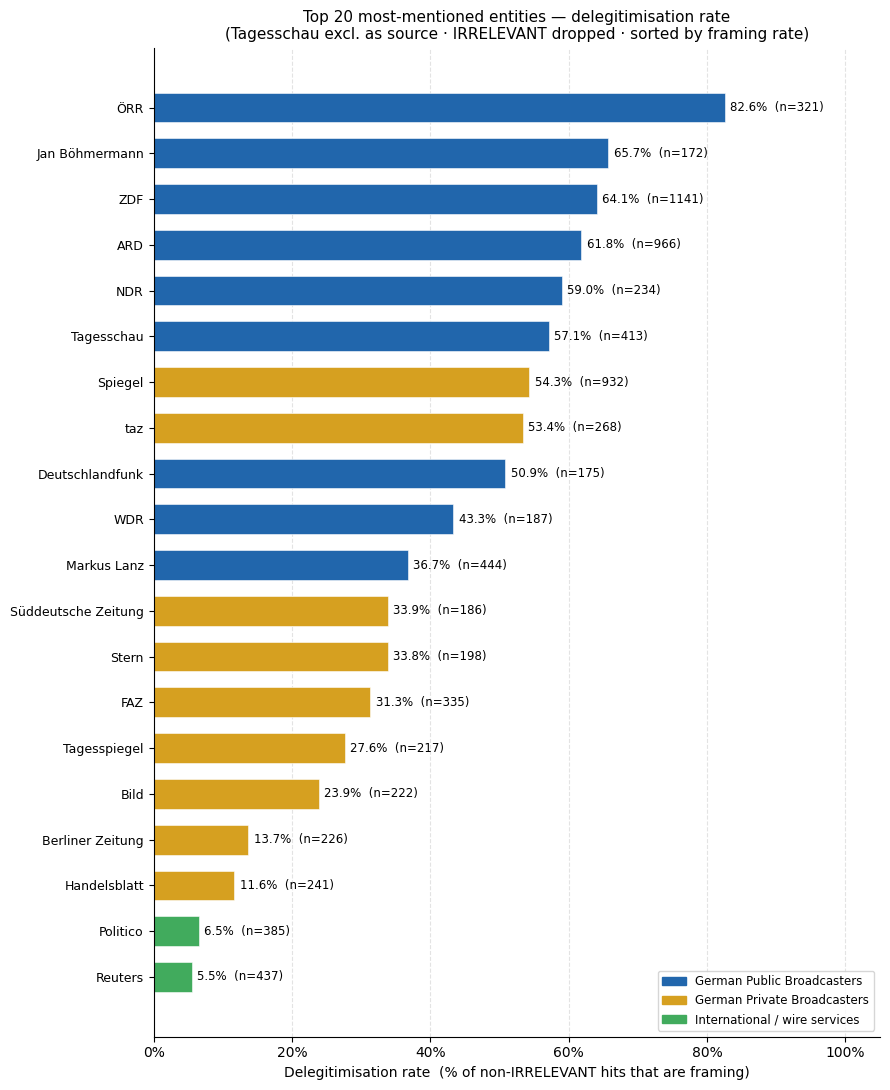

In [13]:
# ── Top 20 most-mentioned entities: delegitimisation rate, coloured by group ──
from matplotlib.patches import Patch

TOP_N = 20

HIT_GROUPS = {
    "German Public Broadcasters": {
        "color": "#2166ac",
        "members": {
            "ÖRR", "ZDF", "ARD", "NDR", "Tagesschau", "Deutschlandfunk",
            "WDR", "Deutschlandradio", "Öffentlich-Rechtliche",
            "Öffentlich-rechtliche Medien", "ÖffentlichRechtliche", "Jan Böhmermann", "Böhmermann", "Markus Lanz", "Lanz"
        },
    },
   
    "German Private Broadcasters": {
        "color": "#d6a020",
        "members": {
            "Spiegel", "Der Spiegel", "taz", "Süddeutsche Zeitung", "SZ",
            "Tagesspiegel", "Stern","FAZ", "Frankfurter Allgemeine Zeitung", "Handelsblatt", "Bild", "Bild-Zeitung", "Berliner Zeitung"
        },
    },
    "International / wire services": {
        "color": "#41ab5d",
        "members": {"Politico", "Reuters", "BBC", "CNN", "AP", "dpa"},
    },
}

hit_to_group = {m: g for g, meta in HIT_GROUPS.items() for m in meta["members"]}

# Delegitimisation rate = framing hits / (framing + neutral) per entity
df_known = df[df["hit_text"].isin(hit_to_group)].copy()

total_hits   = df_known.groupby("hit_text").size()
framing_hits = df_known[df_known["category"] != "NEUTRAL"].groupby("hit_text").size()

deleg = (framing_hits / total_hits).dropna().rename("rate")

# Top N by total hits
top_entities = total_hits.nlargest(TOP_N).index
plot_df = (
    deleg.reindex(top_entities).dropna()
    .reset_index()
    .rename(columns={"hit_text": "entity"})
)
plot_df["n"]      = plot_df["entity"].map(total_hits).astype(int)
plot_df["group"]  = plot_df["entity"].map(hit_to_group)
plot_df["color"]  = plot_df["group"].map(lambda g: HIT_GROUPS[g]["color"])
plot_df = plot_df.sort_values("rate", ascending=True)   # highest at top in barh

fig, ax = plt.subplots(figsize=(9, max(6, len(plot_df) * 0.55)))

bars = ax.barh(plot_df["entity"], plot_df["rate"] * 100,
               color=plot_df["color"], edgecolor="white", linewidth=0.4, height=0.65)

for bar, (_, row) in zip(bars, plot_df.iterrows()):
    pct = row["rate"] * 100
    ax.text(pct + 0.8, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%  (n={row['n']})",
            va="center", fontsize=8.5)

ax.set_xlabel("Delegitimisation rate  (% of non-IRRELEVANT hits that are framing)", fontsize=10)
ax.set_xlim(0, 105)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_title(
    f"Top {TOP_N} most-mentioned entities — delegitimisation rate\n"
    "(Tagesschau excl. as source · IRRELEVANT dropped · sorted by framing rate)",
    fontsize=11,
)
ax.tick_params(axis="y", labelsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.grid(True, linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

legend_handles = [
    Patch(color=meta["color"], label=group)
    for group, meta in HIT_GROUPS.items()
    if group in plot_df["group"].values
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=8.5, frameon=True)

plt.tight_layout()
plt.show()


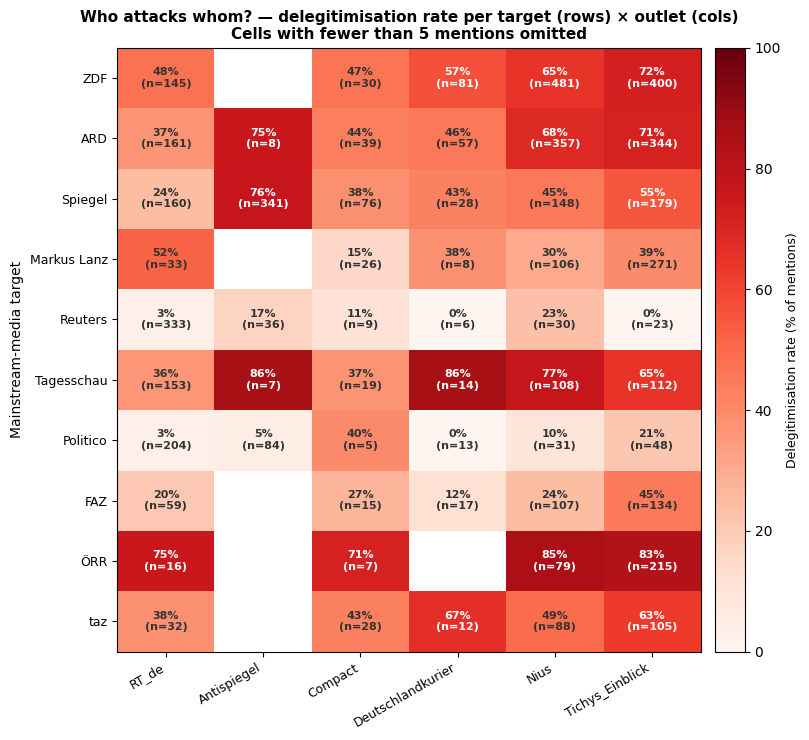

In [14]:
# ── Heatmap: delegitimisation rate per target entity × outlet ────────────────
# Rows = top 10 most-mentioned hit entities (across all outlets)
# Cols = alternative outlets
# Cell = % of mentions that are framing (non-NEUTRAL); blank if n < MIN_N


import matplotlib.colors as mcolors


MIN_N  = 5
TOP_N  = 10

OUTLETS = ["RT_de", "Antispiegel", "Compact", "Deutschlandkurier", "Nius", "Tichys_Einblick"]

# Top N entities by total hit count across all outlets
top_entities = (
    df.groupby("hit_text").size()
    .nlargest(TOP_N)
    .index.tolist()
)

df_sub = df[df["hit_text"].isin(top_entities)].copy()
df_sub = df_sub[df_sub["source"].isin(OUTLETS)]

# Per (entity, outlet): total hits and framing hits
total   = df_sub.groupby(["hit_text", "source"]).size().unstack(fill_value=0)
framing = (
    df_sub[df_sub["category"] != "NEUTRAL"]
    .groupby(["hit_text", "source"]).size()
    .unstack(fill_value=0)
)

# Reindex to full grid
total   = total.reindex(index=top_entities, columns=OUTLETS, fill_value=0)
framing = framing.reindex(index=top_entities, columns=OUTLETS, fill_value=0)

rate = (framing / total.replace(0, np.nan)) * 100  # NaN where no hits
mask = total < MIN_N                                 # cells to blank out
rate_masked = rate.where(~mask, other=np.nan)

# ── Plot ──────────────────────────────────────────────────────────────────────
cmap = plt.cm.Reds
norm = mcolors.Normalize(vmin=0, vmax=100)

fig, ax = plt.subplots(figsize=(max(8, len(OUTLETS) * 1.4),
                                max(5, TOP_N * 0.75)))

im = ax.imshow(rate_masked.values, cmap=cmap, norm=norm, aspect="auto")

# Cell annotations
for r, entity in enumerate(rate_masked.index):
    for c, outlet in enumerate(rate_masked.columns):
        val = rate_masked.iloc[r, c]
        n   = total.iloc[r, c]
        if np.isnan(val):
            continue
        txt_color = "white" if val > 55 else "#333333"
        ax.text(c, r, f"{val:.0f}%\n(n={int(n)})",
                ha="center", va="center", fontsize=8,
                color=txt_color, fontweight="bold")

ax.set_xticks(range(len(OUTLETS)))
ax.set_xticklabels(OUTLETS, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(len(rate_masked.index)))
ax.set_yticklabels(rate_masked.index, fontsize=9)
ax.set_ylabel("Mainstream-media target", fontsize=10)

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Delegitimisation rate (% of mentions)", fontsize=9)

ax.set_title(
    f"Who attacks whom? — delegitimisation rate per target (rows) × outlet (cols)\n"
    f"Cells with fewer than {MIN_N} mentions omitted",
    fontsize=11, fontweight="bold",
)

plt.tight_layout()
plt.show()


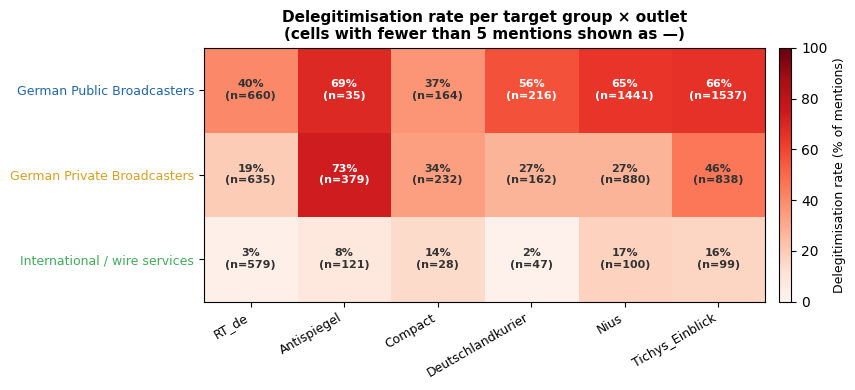

In [16]:
# ── Delegitimisation rate per hit GROUP × outlet ─────────────────────────────
# Groups aggregate all member entities; rows = groups, cols = outlets
# Reuses HIT_GROUPS defined in cell above


# Tag every row with its group
df["hit_group"] = df["hit_text"].map(hit_to_group)   # NaN for unrecognised entities
df_grp = df[df["hit_group"].notna() & df["source"].isin(OUTLETS)].copy()

# Aggregate: total and framing hits per (group, outlet)
total_g   = df_grp.groupby(["hit_group", "source"]).size().unstack(fill_value=0)
framing_g = (
    df_grp[df_grp["category"] != "NEUTRAL"]
    .groupby(["hit_group", "source"]).size()
    .unstack(fill_value=0)
)

group_order = list(HIT_GROUPS.keys())
total_g   = total_g.reindex(index=group_order, columns=OUTLETS, fill_value=0)
framing_g = framing_g.reindex(index=group_order, columns=OUTLETS, fill_value=0)

rate_g   = (framing_g / total_g.replace(0, np.nan)) * 100
mask_g   = total_g < MIN_N
rate_vis = rate_g.where(~mask_g, other=np.nan)

# ── Heatmap ───────────────────────────────────────────────────────────────────
cmap = plt.cm.Reds
norm = mcolors.Normalize(vmin=0, vmax=100)

fig, ax = plt.subplots(figsize=(max(9, len(OUTLETS) * 1.5),
                                max(4, len(group_order) * 0.8)))

im = ax.imshow(rate_vis.values, cmap=cmap, norm=norm, aspect="auto")

for r, group in enumerate(rate_vis.index):
    for c, outlet in enumerate(rate_vis.columns):
        val = rate_vis.iloc[r, c]
        n   = total_g.iloc[r, c]
        if np.isnan(val):
            ax.text(c, r, "—", ha="center", va="center", fontsize=9, color="#aaaaaa")
            continue
        txt_color = "white" if val > 55 else "#333333"
        ax.text(c, r, f"{val:.0f}%\n(n={int(n)})",
                ha="center", va="center", fontsize=8,
                color=txt_color, fontweight="bold")

# Colour the y-tick labels by group colour
ax.set_xticks(range(len(OUTLETS)))
ax.set_xticklabels(OUTLETS, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(len(group_order)))
ax.set_yticklabels(group_order, fontsize=9)
for tick, group in zip(ax.get_yticklabels(), group_order):
    tick.set_color(HIT_GROUPS[group]["color"])

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Delegitimisation rate (% of mentions)", fontsize=9)

ax.set_title(
    "Delegitimisation rate per target group × outlet\n"
    f"(cells with fewer than {MIN_N} mentions shown as —)",
    fontsize=11, fontweight="bold",
)

plt.tight_layout()
plt.show()
